In [ ]:
import csv
import re
import sqlite3
import sys
from datetime import date
from pathlib import Path

# alfa_agent лежит в корне репозитория, на уровень выше этой папки.
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from alfa_agent.llm import get_client, render

DB_PATH = "gospodderzhka.db"
SCHEMA_PATH = "schema.sql"
CSV_PATH = "mery-podderzhki-msp-2026.csv"
SNAPSHOT_DATE = "2026-07-19"
AS_OF = "2026-07-19"
DRAFT_THRESHOLD = 2

In [14]:
def build_database() -> sqlite3.Connection:
    Path(DB_PATH).unlink(missing_ok=True)
    conn = sqlite3.connect(DB_PATH)
    conn.execute("PRAGMA foreign_keys = ON")
    conn.executescript(Path(SCHEMA_PATH).read_text(encoding="utf-8"))
    conn.row_factory = sqlite3.Row
    return conn

In [15]:
def to_int(value):
    value = (value or "").strip()
    if not value:
        return None
    try:
        return int(float(value))
    except ValueError:
        return None


def load_raw_programs(conn: sqlite3.Connection) -> int:
    with open(CSV_PATH, encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f, delimiter=";")
        rows = [
            (
                r["id"], "csv_manual", r["Мера"], r.get("Организатор"), r.get("Уровень"),
                r.get("Тип"), r.get("Аудитория"), r.get("Возраст"),
                to_int(r.get("Сумма_мин_руб")), to_int(r.get("Сумма_макс_руб")),
                r.get("Софинансирование"), r.get("Окно_2026"), r.get("Статус_на_19.07.2026"),
                r.get("Постоянный_прием"), r.get("Канал_подачи"), r.get("Ключевые_условия"),
                r.get("Стоп-факторы"), r.get("Источник"), r.get("Верифицировано"),
                r.get("Примечание"), SNAPSHOT_DATE,
            )
            for r in reader
        ]

    conn.executemany(
        """INSERT INTO raw_program_source (
            external_id, source_type, name_raw, organizer_raw, level_raw, type_raw,
            audience_text, age_text, amount_min_raw, amount_max_raw, cofinancing_text,
            window_text, status_text, is_permanent_intake_raw, submission_channel_raw,
            key_conditions_text, stop_factors_text, source_url, verified_label, note_text,
            snapshot_date
        ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
        rows,
    )
    conn.commit()
    return len(rows)

In [16]:
LEVEL_MAP = {"федеральный": "federal", "региональный": "regional", "федерально-региональный": "mixed"}
TYPE_MAP = {
    "грант": "grant", "субсидия": "subsidy", "льготный кредит": "credit",
    "льготный заём": "credit", "гарантия": "guarantee", "лизинг": "leasing",
    "нефинансовая": "nonfinancial",
}
AGE_RANGE_RE = re.compile(r"(\d{1,2})\s*[–\-]\s*(\d{1,2})\s*лет")
AGE_FROM_RE = re.compile(r"с\s*(\d{1,2})\s*лет")


def parse_age(age_text):
    if not age_text:
        return None, None, "unparsed"
    text = age_text.strip().lower()
    if text.startswith("без ограничения"):
        return None, None, "parsed"
    m = AGE_RANGE_RE.search(text)
    if m:
        return int(m.group(1)), int(m.group(2)), "parsed"
    m = AGE_FROM_RE.search(text)
    if m:
        return int(m.group(1)), None, "parsed"
    return None, None, "unparsed"


def parse_is_open(status_text):
    if not status_text:
        return 0
    text = status_text.lower()
    if "закрыт" in text and "не закрыт" not in text:
        return 0
    if "открыт" in text or "действует" in text:
        return 1
    return 0


def parse_cofinancing(text):
    return 0 if not text or text.strip().lower() == "нет" else 1


def parse_submission_channel(text):
    if not text:
        return "other"
    t = text.lower()
    if "банк" in t:
        return "bank"
    if "госуслуги" in t:
        return "gosuslugi"
    if "фонд-м" in t or "fasie" in t or "мсп.рф" in t:
        return "fund_platform"
    if "мой бизнес" in t or "мфц" in t or "минсельхоз" in t or "региональный орган" in t:
        return "regional_office"
    return "other"


def normalize_programs(conn: sqlite3.Connection) -> int:
    raw_rows = conn.execute("SELECT * FROM raw_program_source").fetchall()
    for r in raw_rows:
        age_min, age_max, age_conf = parse_age(r["age_text"])
        conn.execute(
            """INSERT INTO support_program (
                raw_source_id, name, organizer, level, type, amount_min, amount_max,
                cofinancing_required, age_min, age_max, age_parse_confidence,
                is_open, status_checked_at, submission_channel, stop_factors_text,
                notes_text, last_verified_at
            ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
            (
                r["source_row_id"], r["name_raw"], r["organizer_raw"],
                LEVEL_MAP.get(r["level_raw"], "federal"), TYPE_MAP.get(r["type_raw"], "grant"),
                r["amount_min_raw"], r["amount_max_raw"], parse_cofinancing(r["cofinancing_text"]),
                age_min, age_max, age_conf,
                parse_is_open(r["status_text"]), r["snapshot_date"],
                parse_submission_channel(r["submission_channel_raw"]),
                r["stop_factors_text"], r["note_text"], r["snapshot_date"],
            ),
        )
    conn.commit()
    return len(raw_rows)

In [17]:
DOCUMENT_TYPES = [
    "бизнес-план", "документ на помещение (аренда/собственность)",
    "справка об отсутствии задолженности", "выписка по счёту",
    "заявление по установленной форме", "финансовая отчётность",
]
REQUIRED_DOCS_BY_PROGRAM = {
    "agro-bakery": ["бизнес-план", "документ на помещение (аренда/собственность)",
                    "справка об отсутствии задолженности", "выписка по счёту"],
    "program-1764": ["заявление по установленной форме", "финансовая отчётность",
                      "выписка по счёту", "справка об отсутствии задолженности"],
}
CLIENT_HAS_DOCS = ["выписка по счёту", "справка об отсутствии задолженности"]


def seed_demo_data(conn: sqlite3.Connection) -> tuple:
    doc_type_ids = {}
    for name in DOCUMENT_TYPES:
        cur = conn.execute("INSERT INTO document_type (name) VALUES (?)", (name,))
        doc_type_ids[name] = cur.lastrowid

    for external_id, doc_names in REQUIRED_DOCS_BY_PROGRAM.items():
        row = conn.execute(
            """SELECT sp.program_id FROM support_program sp
               JOIN raw_program_source rps ON rps.source_row_id = sp.raw_source_id
               WHERE rps.external_id = ?""",
            (external_id,),
        ).fetchone()
        if row:
            for doc_name in doc_names:
                conn.execute(
                    "INSERT INTO required_document (program_id, document_type_id) VALUES (?,?)",
                    (row["program_id"], doc_type_ids[doc_name]),
                )

    cur = conn.execute(
        """INSERT INTO client (full_name, birth_date, entity_type, industry_code,
                                business_registered_at, region_code)
           VALUES (?,?,?,?,?,?)""",
        ("Дарья Кузнецова", "2001-05-14", "ИП", "производство хлебобулочных изделий",
         "2024-03-01", "Ленинградская область"),
    )
    client_id = cur.lastrowid
    for doc_name in CLIENT_HAS_DOCS:
        conn.execute(
            "INSERT INTO client_document (client_id, document_type_id, status) VALUES (?,?,'verified')",
            (client_id, doc_type_ids[doc_name]),
        )
    conn.commit()
    return client_id, doc_type_ids

In [18]:
def client_age(birth_date: str, as_of: str) -> int:
    b, a = date.fromisoformat(birth_date), date.fromisoformat(as_of)
    return a.year - b.year - ((a.month, a.day) < (b.month, b.day))


def check_eligibility(client, program):
    if not program["is_open"]:
        return False, "Приём заявок по этой программе сейчас закрыт или требует уточнения статуса."
    if program["age_min"] is not None or program["age_max"] is not None:
        age = client_age(client["birth_date"], AS_OF)
        lo, hi = program["age_min"] or 0, program["age_max"] or 200
        if not (lo <= age <= hi):
            return False, f"Возраст клиента ({age}) не входит в диапазон {lo}-{hi} лет."
    return True, "Клиент проходит по всем распознанным критериям (открытый приём, возраст)."


def run_matching(conn: sqlite3.Connection, client_id: int) -> list:
    client = conn.execute("SELECT * FROM client WHERE client_id=?", (client_id,)).fetchone()
    programs = conn.execute("SELECT * FROM support_program").fetchall()
    results = []
    for program in programs:
        is_eligible, reason = check_eligibility(client, program)
        conn.execute(
            "INSERT INTO eligibility_check (client_id, program_id, is_eligible, reason_text) VALUES (?,?,?,?)",
            (client_id, program["program_id"], int(is_eligible), reason),
        )
        results.append({"program": program, "is_eligible": is_eligible, "reason": reason})
    conn.commit()
    return results

In [19]:
def missing_documents(conn: sqlite3.Connection, client_id: int, program_id: int) -> list:
    rows = conn.execute(
        """SELECT dt.name FROM required_document rd
           JOIN document_type dt ON dt.document_type_id = rd.document_type_id
           WHERE rd.program_id = ?
             AND rd.document_type_id NOT IN (
                 SELECT cd.document_type_id FROM client_document cd
                 WHERE cd.client_id = ? AND cd.status = 'verified'
             )""",
        (program_id, client_id),
    ).fetchall()
    return [r["name"] for r in rows]

In [20]:
def decide(is_eligible: bool, missing: list) -> str:
    if not is_eligible:
        return "not_eligible"
    if len(missing) <= DRAFT_THRESHOLD:
        return "propose_draft"
    return "request_documents"

In [ ]:
def explain_eligibility(client, program, is_eligible, reason):
    llm_client = get_client()
    system, user = render(
        "eligibility_explainer",
        client_name=client["full_name"],
        entity_type=client["entity_type"],
        industry=client["industry_code"],
        program_name=program["name"],
        organizer=program["organizer"],
        verdict="подходит" if is_eligible else "не подходит",
        reason=reason,
    )
    return llm_client.generate(system=system, user=user)


def draft_application(client, program, missing):
    missing_str = ", ".join(missing) if missing else "нет — все документы уже есть у банка"
    llm_client = get_client()
    system, user = render(
        "application_draft",
        program_name=program["name"],
        organizer=program["organizer"],
        client_name=client["full_name"],
        entity_type=client["entity_type"],
        industry=client["industry_code"],
        region=client["region_code"],
        registered_at=client["business_registered_at"],
        missing_documents=missing_str,
    )
    return llm_client.generate(system=system, user=user)

In [22]:
import matplotlib.pyplot as plt

ALFA_RED = "#EF3124"
ALFA_BLACK = "#000000"
ALFA_GRAY = "#B5B5B5"
ALFA_WHITE = "#FFFFFF"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["text.color"] = ALFA_BLACK
plt.rcParams["axes.edgecolor"] = ALFA_BLACK
plt.rcParams["axes.labelcolor"] = ALFA_BLACK
plt.rcParams["xtick.color"] = ALFA_BLACK
plt.rcParams["ytick.color"] = ALFA_BLACK

TYPE_LABELS_RU = {
    "grant": "Гранты", "credit": "Льготные кредиты", "guarantee": "Гарантии",
    "leasing": "Лизинг", "subsidy": "Субсидии", "nonfinancial": "Нефинансовые",
}

In [23]:
def plot_overview(conn: sqlite3.Connection, client_id: int):
    programs = conn.execute("SELECT * FROM support_program").fetchall()
    results = conn.execute(
        "SELECT * FROM eligibility_check WHERE client_id = ?", (client_id,)
    ).fetchall()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), facecolor=ALFA_WHITE)
    fig.suptitle("ИИ-помощник по господдержке — обзор", fontsize=15, fontweight="bold", color=ALFA_BLACK)

    type_counts = {}
    for p in programs:
        label = TYPE_LABELS_RU.get(p["type"], p["type"])
        type_counts[label] = type_counts.get(label, 0) + 1
    ax = axes[0, 0]
    ax.set_facecolor(ALFA_WHITE)
    ax.bar(type_counts.keys(), type_counts.values(), color=ALFA_RED)
    ax.set_title("Программы по типу", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

    n_open = sum(1 for p in programs if p["is_open"])
    n_closed = len(programs) - n_open
    ax = axes[0, 1]
    ax.pie(
        [n_open, n_closed],
        labels=[f"Открыт ({n_open})", f"Закрыт/неясен ({n_closed})"],
        autopct="%1.0f%%", colors=[ALFA_RED, ALFA_GRAY], startangle=90,
        textprops={"color": ALFA_BLACK},
        wedgeprops={"edgecolor": ALFA_WHITE, "linewidth": 1.5},
    )
    ax.set_title("Статус приёма заявок", fontweight="bold")

    n_eligible = sum(1 for r in results if r["is_eligible"])
    n_not = len(results) - n_eligible
    ax = axes[1, 0]
    ax.set_facecolor(ALFA_WHITE)
    ax.bar(["Подходит", "Не подходит"], [n_eligible, n_not], color=[ALFA_RED, ALFA_GRAY])
    ax.set_title(f"Результат для клиента ({len(results)} программ)", fontweight="bold")
    for i, v in enumerate([n_eligible, n_not]):
        ax.text(i, v + 0.2, str(v), ha="center", fontweight="bold", color=ALFA_BLACK)

    decision_labels = {
        "propose_draft": "Предложить черновик",
        "request_documents": "Запросить документы",
        "not_eligible": "Не подходит",
    }
    decision_counts = {"propose_draft": 0, "request_documents": 0, "not_eligible": 0}
    for r in results:
        missing = missing_documents(conn, client_id, r["program_id"]) if r["is_eligible"] else []
        decision_counts[decide(r["is_eligible"], missing)] += 1

    ax = axes[1, 1]
    ax.set_facecolor(ALFA_WHITE)
    colors_by_decision = {"propose_draft": ALFA_RED, "request_documents": ALFA_BLACK, "not_eligible": ALFA_GRAY}
    names = [decision_labels[k] for k in decision_counts]
    values = list(decision_counts.values())
    ax.bar(names, values, color=[colors_by_decision[k] for k in decision_counts])
    ax.set_title("Решения агента (20 программ)", fontweight="bold")
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(values):
        ax.text(i, v + 0.2, str(v), ha="center", fontweight="bold", color=ALFA_BLACK)

    for ax in axes.flat:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig("overview.png", dpi=150, bbox_inches="tight", facecolor=ALFA_WHITE)
    plt.show()
    print("Сохранено: overview.png")

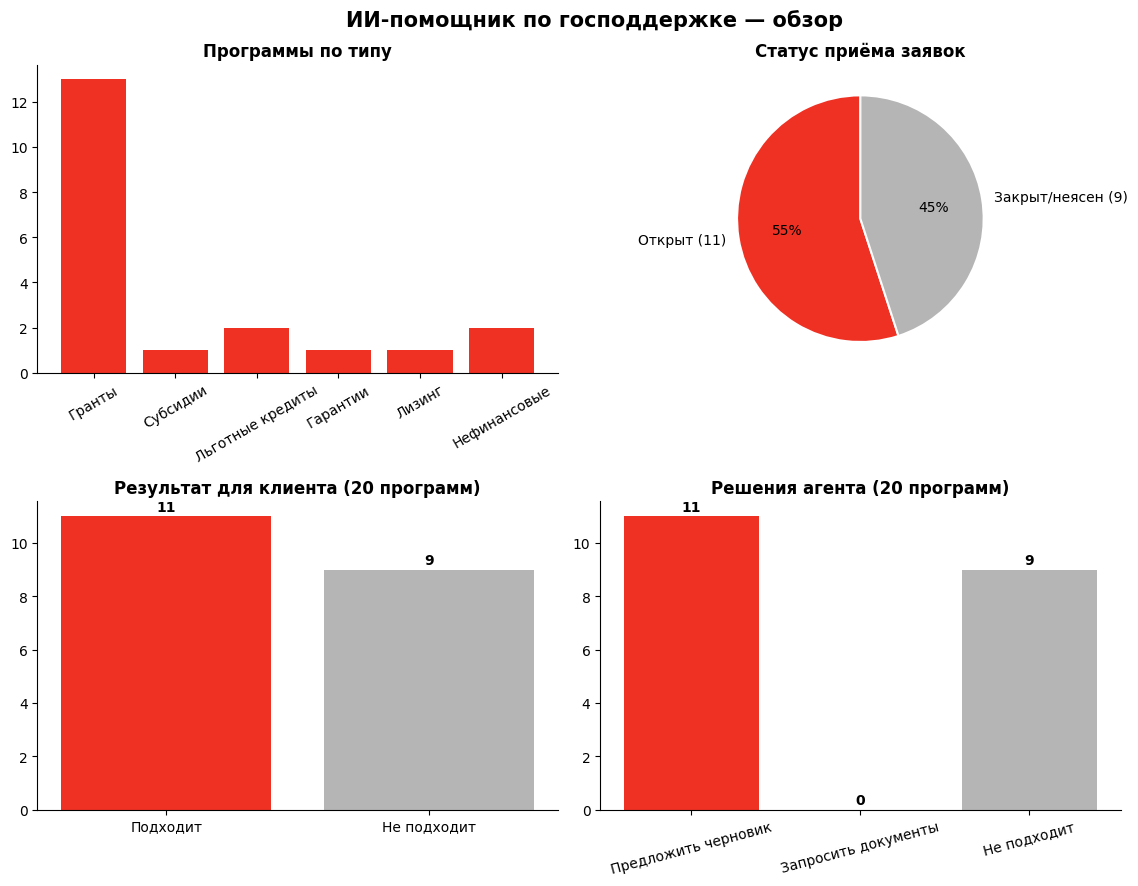

Сохранено: overview.png


In [24]:
conn = build_database()
load_raw_programs(conn)
normalize_programs(conn)
client_id, doc_type_ids = seed_demo_data(conn)
run_matching(conn, client_id)

plot_overview(conn, client_id)

In [29]:
import random
import time

ORGANIZERS = [
    "Фонд содействия инновациям", "Минсельхоз региона", "Корпорация МСП",
    "Минэкономразвития региона", "Росмолодёжь", "АО «МСП Банк»",
    "Региональный фонд поддержки предпринимательства", "Мой бизнес",
]
LEVELS_RAW = ["федеральный", "региональный", "федерально-региональный"]
TYPES_RAW = ["грант", "субсидия", "льготный кредит", "льготный заём", "гарантия", "лизинг", "нефинансовая"]
AGE_TEXTS = [
    "без ограничения", "14–25 лет включительно", "14–35 лет включительно",
    "с 18 лет", "с 21 год", "18–45 лет включительно",
]
STATUS_TEXTS = [
    "программа действует", "действует", "приём закрыт",
    "зависит от региона, уточнять", "требует проверки на сайте", "приём открыт",
]
COFINANCING_TEXTS = ["нет", "требуется", "требуется внебюджетное", "10–40% на выбор", "25%"]
CHANNEL_TEXTS = [
    "банк", "Госуслуги", "сайт фонда (Фонд-М)", "МСП.РФ",
    "региональный орган власти", "центр «Мой бизнес»", "МФЦ",
]
NAME_TEMPLATES = [
    "Грант на развитие {sector}", "Субсидия для {sector}", "Льготный кредит для {sector}",
    "Программа поддержки {sector}", "Микрозаём для {sector}", "Лизинг оборудования для {sector}",
]
SECTORS = [
    "общепита", "сельского хозяйства", "лёгкой промышленности", "туризма",
    "IT-стартапов", "производства стройматериалов", "розничной торговли",
    "экспортёров", "социального предпринимательства", "ремесленников",
]


def generate_synthetic_rows(n: int, seed: int = 42) -> list:
    rnd = random.Random(seed)
    rows = []
    for i in range(n):
        sector = rnd.choice(SECTORS)
        name = rnd.choice(NAME_TEMPLATES).format(sector=sector)
        amount_min = rnd.choice([None, 100_000, 300_000, 500_000])
        amount_max = rnd.choice([1_000_000, 3_000_000, 5_000_000, 10_000_000, 50_000_000])
        rows.append(
            (
                f"synthetic-{i:05d}", "synthetic", name, rnd.choice(ORGANIZERS),
                rnd.choice(LEVELS_RAW), rnd.choice(TYPES_RAW),
                f"субъекты МСП в сфере {sector}", rnd.choice(AGE_TEXTS),
                amount_min, amount_max, rnd.choice(COFINANCING_TEXTS), "",
                rnd.choice(STATUS_TEXTS), rnd.choice(["да", "нет"]), rnd.choice(CHANNEL_TEXTS),
                f"регистрация не ранее {rnd.choice([1,2,3,5])} лет назад",
                "наличие задолженности по налогам", "", "нет — синтетические данные",
                "Сгенерировано для нагрузочного теста", SNAPSHOT_DATE,
            )
        )
    return rows


def load_synthetic_programs(conn: sqlite3.Connection, n: int) -> int:
    rows = generate_synthetic_rows(n)
    conn.executemany(
        """INSERT INTO raw_program_source (
            external_id, source_type, name_raw, organizer_raw, level_raw, type_raw,
            audience_text, age_text, amount_min_raw, amount_max_raw, cofinancing_text,
            window_text, status_text, is_permanent_intake_raw, submission_channel_raw,
            key_conditions_text, stop_factors_text, source_url, verified_label, note_text,
            snapshot_date
        ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
        rows,
    )
    conn.commit()
    return len(rows)


def generate_synthetic_required_documents(conn: sqlite3.Connection, doc_type_ids: dict, seed: int = 43) -> int:
    rnd = random.Random(seed)
    doc_names = list(doc_type_ids.keys())
    rows = conn.execute(
        """SELECT sp.program_id FROM support_program sp
           JOIN raw_program_source rps ON rps.source_row_id = sp.raw_source_id
           WHERE rps.source_type = 'synthetic'"""
    ).fetchall()
    inserted = 0
    for r in rows:
        n_docs = rnd.choice([0, 1, 2, 3, 4, 5])
        chosen = rnd.sample(doc_names, min(n_docs, len(doc_names)))
        for name in chosen:
            conn.execute(
                "INSERT INTO required_document (program_id, document_type_id) VALUES (?,?)",
                (r["program_id"], doc_type_ids[name]),
            )
            inserted += 1
    conn.commit()
    return inserted

In [30]:
def plot_load_test(n_synthetic: int = 1000):
    conn = build_database()
    n_real = load_raw_programs(conn)
    n_synth = load_synthetic_programs(conn, n_synthetic)
    normalize_programs(conn)
    client_id, doc_type_ids = seed_demo_data(conn)
    generate_synthetic_required_documents(conn, doc_type_ids)
    results = run_matching(conn, client_id)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), facecolor=ALFA_WHITE)
    fig.suptitle(
        f"Нагрузочный тест — {n_real + n_synth} программ ({n_real} реальных + {n_synth} синтетических)",
        fontsize=14, fontweight="bold", color=ALFA_BLACK,
    )

    ax = axes[0, 0]
    ax.set_facecolor(ALFA_WHITE)
    ax.bar(["Реальные", "Синтетика"], [n_real, n_synth], color=[ALFA_RED, ALFA_GRAY])
    ax.set_title("Состав данных", fontweight="bold")
    for i, v in enumerate([n_real, n_synth]):
        ax.text(i, v + max(n_real, n_synth) * 0.01, str(v), ha="center", fontweight="bold", color=ALFA_BLACK)

    programs = conn.execute("SELECT * FROM support_program").fetchall()
    type_counts = {}
    for p in programs:
        label = TYPE_LABELS_RU.get(p["type"], p["type"])
        type_counts[label] = type_counts.get(label, 0) + 1
    ax = axes[0, 1]
    ax.set_facecolor(ALFA_WHITE)
    ax.bar(type_counts.keys(), type_counts.values(), color=ALFA_RED)
    ax.set_title("Программы по типу", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

    n_eligible = sum(1 for r in results if r["is_eligible"])
    n_not = len(results) - n_eligible
    ax = axes[1, 0]
    ax.set_facecolor(ALFA_WHITE)
    ax.bar(["Подходит", "Не подходит"], [n_eligible, n_not], color=[ALFA_RED, ALFA_GRAY])
    ax.set_title(f"Результат для клиента ({len(results)} программ)", fontweight="bold")
    for i, v in enumerate([n_eligible, n_not]):
        ax.text(i, v + len(results) * 0.01, str(v), ha="center", fontweight="bold", color=ALFA_BLACK)

    decision_labels = {
        "propose_draft": "Предложить черновик",
        "request_documents": "Запросить документы",
        "not_eligible": "Не подходит",
    }
    decision_counts = {"propose_draft": 0, "request_documents": 0, "not_eligible": 0}
    for r in results:
        missing = missing_documents(conn, client_id, r["program"]["program_id"]) if r["is_eligible"] else []
        decision_counts[decide(r["is_eligible"], missing)] += 1

    ax = axes[1, 1]
    ax.set_facecolor(ALFA_WHITE)
    colors_by_decision = {"propose_draft": ALFA_RED, "request_documents": ALFA_BLACK, "not_eligible": ALFA_GRAY}
    names = [decision_labels[k] for k in decision_counts]
    values = list(decision_counts.values())
    ax.bar(names, values, color=[colors_by_decision[k] for k in decision_counts])
    ax.set_title("Решения агента", fontweight="bold")
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(values):
        ax.text(i, v + len(results) * 0.01, str(v), ha="center", fontweight="bold", color=ALFA_BLACK)

    for ax in axes.flat:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig("load_test.png", dpi=150, bbox_inches="tight", facecolor=ALFA_WHITE)
    plt.show()
    conn.close()
    print("Сохранено: load_test.png")

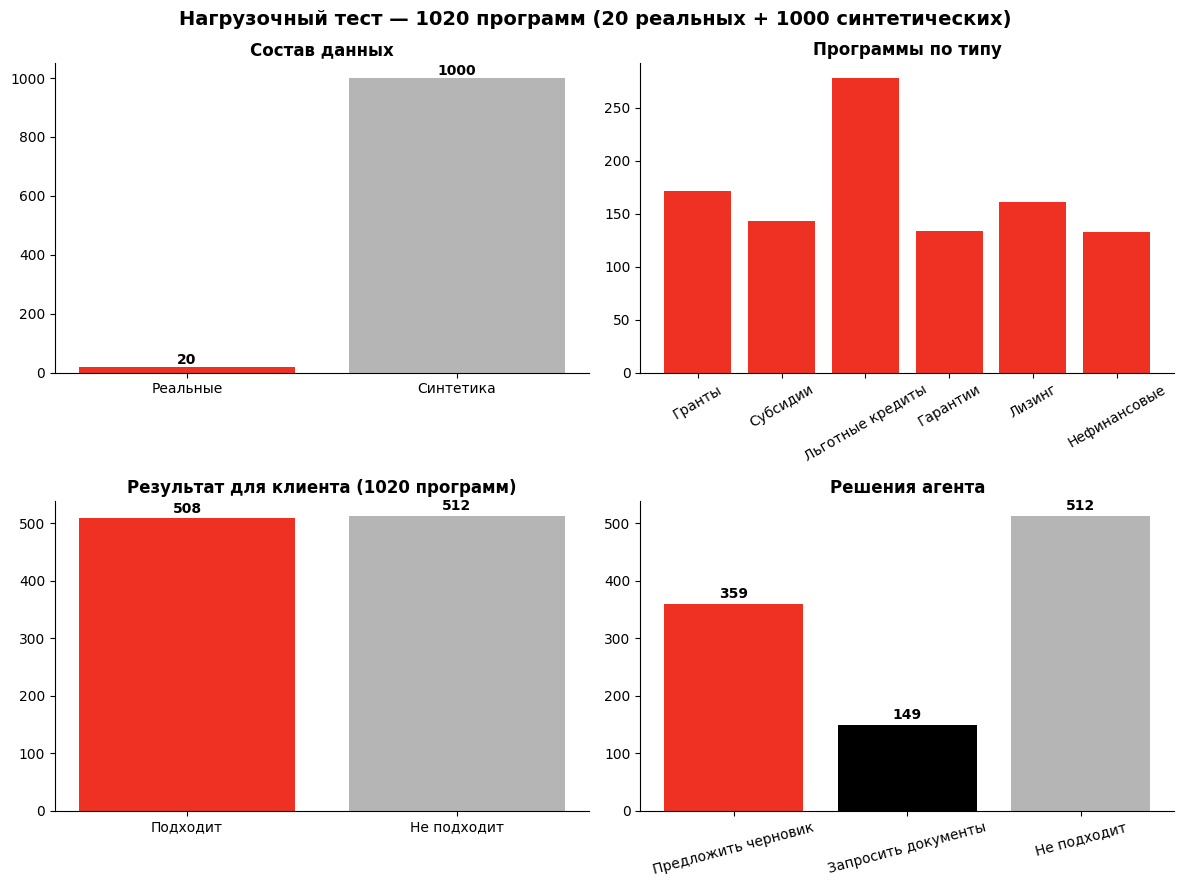

Сохранено: load_test.png


In [31]:
plot_load_test(1000)